untuk mengerjakan skripsi penerjemah bahasa isyarat sibi mengunakan cnn dan lstm

# import library

In [1]:
!pip uninstall mediapipe
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 43.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [2]:
import cv2
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import mediapipe as mp
from tensorflow.keras.models import Model
from tensorflow.keras.layers import TimeDistributed, Flatten, LSTM, Dense, Dropout, Input, GlobalAveragePooling2D,BatchNormalization
from tensorflow.keras.applications import Xception
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import Image, display

# Akuisisi Data

## memanggil folder data

In [3]:
raw_folder_path = '/content/drive/MyDrive/raw'

# Periksa apakah folder tersebut ada
if os.path.exists(raw_folder_path):
    print(f"Folder 'raw' ditemukan di: {raw_folder_path}")
    print("Isi folder 'raw' (urutan abjad):")
    for item in sorted(os.listdir(raw_folder_path)):
        print(item)
else:
    print(f"Folder 'raw' tidak ditemukan di: {raw_folder_path}")
    print("Pastikan folder 'raw' ada di Google Drive Anda dan path yang diberikan sudah benar.")

Folder 'raw' ditemukan di: /content/drive/MyDrive/raw
Isi folder 'raw' (urutan abjad):
akhiran-an
akhiran-i
akhiran-kan
akhiran-man
akhiran-nya
akhiran-ti
akhiran-wan
akhiran-wati
apa
awalan-ber
awalan-di
awalan-ke
awalan-me
awalan-pe
awalan-se
awalan-ter
baca
bagaimana
balai
bantu
bawa
beli
benar
berapa
bicara
bisa
buka
buku
cari
datang
dengar
desa
dia
dosen
duduk
gedung
guna
guru
hari
ingat
ini
itu
jalan
jalan-jalan
jawab
kamar
kami
kamu
kapan
keluarga
kendaraan
kerja
kita
kursi
lihat
lupa
makan
malam
mana
mau
meja
mengapa
mereka
minum
motor
mudah
mulai
nanti
nasi
orang
pagi
partike-pun
partikel-kah
partikel-lah
pasar
pergi
perlu
rumah
salah
satu
saya
sedih
sekarang
sekolah
selamat
selesai
senang
siapa
sore
suka
sulit
tahu
tanya
tas
teh
telepon
teman
tidur
tinggal
toko
tunggu
tutup
uang
waktu


# Processing Data

In [4]:
root_raw_dir = raw_folder_path
output_root = 'data/processed'

num_frames_to_save = 20
target_size = (128,128)


for label in sorted(os.listdir(root_raw_dir)):

    word_path = os.path.join(root_raw_dir, label)

    if not os.path.isdir(word_path):
        continue

    print(f"Processing label: {label}")

    output_label_dir = os.path.join(output_root, label)

    os.makedirs(output_label_dir, exist_ok=True)

    for video_name in sorted(os.listdir(word_path)):

        if not video_name.lower().endswith('.webm') and not video_name.lower().endswith('.mp4'):
            continue

        video_full_path = os.path.join(word_path, video_name)
        video_base_name = os.path.splitext(video_name)[0]

        cap = cv2.VideoCapture(video_full_path)

        if not cap.isOpened():
            print(f"Gagal membuka video: {video_name}")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            print(f"Video rusak: {video_name}")
            cap.release()
            continue

        step = max(1, total_frames // num_frames_to_save)

        for i in range(num_frames_to_save):

            frame_id = i * step
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

            ret, frame = cap.read()
            if not ret:
                break

            frame_res = cv2.resize(frame, target_size)

            h, w = frame_res.shape[:2]
            # crop hanya yang berkestensi .webm
            if video_name.lower().endswith('.webm'):
              crop_top = int(h * 0.25)
              frame_crop = frame_res[crop_top:h, 0:w]
            else:
              frame_crop = frame_res

            # resize lagi agar tetap 128x128
            frame_crop = cv2.resize(frame_crop, target_size)

            # Save RGB frame
            rgb_name = f"{video_base_name}_f{i:02d}.jpg"
            cv2.imwrite(os.path.join(output_label_dir, rgb_name), frame_crop)

        cap.release()

        print(f"   selesai: {video_name}")

print("\nSemua video selesai diproses.")

Processing label: akhiran-an
   selesai: Akhiran-An-cam-1.mp4
   selesai: Akhiran-An.webm
   selesai: akhiran-an-1.mp4
   selesai: akhiran-an-cam-4.mp4
   selesai: akhiran-an.mp4
   selesai: awalan-an-2.mp4
Processing label: akhiran-i
   selesai: Akhiran-I-cam-1.mp4
   selesai: Akhiran-I-cam-4.mp4
   selesai: Akhiran-I.webm
   selesai: akhiran-i-1.mp4
   selesai: akhiran-i-cam-2.mp4
   selesai: akhiran-i.mp4
   selesai: awalan-pe-1.mp4
Processing label: akhiran-kan
   selesai: Akhiran-Kan-cam-1.mp4
   selesai: Akhiran-Kan.webm
   selesai: akhiran-kan-1.mp4
   selesai: akhiran-kan-2.mp4
   selesai: akhiran-kan-cam-2.mp4
   selesai: akhiran-kan.mp4
Processing label: akhiran-man
   selesai: Akhiran-Man-cam-1.mp4
   selesai: Akhiran-Man.webm
   selesai: akhiran-man-2.mp4
   selesai: akhiran-man-cam-2.mp4
   selesai: akhiran-man.mp4
   selesai: akhiran-man2.mp4
Processing label: akhiran-nya
   selesai: Akhiran-Nya-cam-1.mp4
   selesai: Akhiran-Nya.webm
   selesai: akhiran-nya-1.mp4
   seles

# Data Cleaning

In [5]:
INPUT_HANDS_DIR = 'data/processed'

def clean_hand_images(input_dir):
    print("Starting hand image cleaning...")
    deleted_count = 0
    total_images = 0

    for label in sorted(os.listdir(input_dir)):
        label_path = os.path.join(input_dir, label)

        if not os.path.isdir(label_path):
            continue

        print(f"  Cleaning label: {label}")

        for img_name in sorted(os.listdir(label_path)):
            total_images += 1
            img_full_path = os.path.join(label_path, img_name)

            try:
                img = cv2.imread(img_full_path)

                # Check for corrupted files
                if img is None:
                    print(f"    Deleting corrupted/unreadable image: {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

                # Check for empty images
                if img.size == 0:
                    print(f"    Deleting empty image: {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

                # Check if the image is mostly black
                if np.mean(img) < 10:
                    print(f"    Deleting mostly black image (likely no hand): {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

            except Exception as e:
                print(f"    Error processing {img_full_path}: {e}. Deleting file.")
                os.remove(img_full_path)
                deleted_count += 1
                continue

    print(f"Cleaning complete. Total images checked: {total_images}, Deleted: {deleted_count}")

clean_hand_images(INPUT_HANDS_DIR)

Starting hand image cleaning...
  Cleaning label: akhiran-an
  Cleaning label: akhiran-i
  Cleaning label: akhiran-kan
  Cleaning label: akhiran-man
  Cleaning label: akhiran-nya
  Cleaning label: akhiran-ti
  Cleaning label: akhiran-wan
  Cleaning label: akhiran-wati
  Cleaning label: apa
  Cleaning label: awalan-ber
  Cleaning label: awalan-di
  Cleaning label: awalan-ke
  Cleaning label: awalan-me
  Cleaning label: awalan-pe
  Cleaning label: awalan-se
  Cleaning label: awalan-ter
  Cleaning label: baca
  Cleaning label: bagaimana
  Cleaning label: balai
  Cleaning label: bantu
  Cleaning label: bawa
  Cleaning label: beli
  Cleaning label: benar
  Cleaning label: berapa
  Cleaning label: bicara
  Cleaning label: bisa
  Cleaning label: buka
  Cleaning label: buku
  Cleaning label: cari
  Cleaning label: datang
  Cleaning label: dengar
  Cleaning label: desa
  Cleaning label: dia
  Cleaning label: dosen
  Cleaning label: duduk
  Cleaning label: gedung
  Cleaning label: guna
  Cleanin

# Ekstraksi fitur

## media pipe

In [6]:
# MEDIAPIPE SETUP
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5
)

# CROP HAND FUNCTION
def crop_and_save_hand_images(
    image_path,
    output_dir,
    label,
    target_size=(128, 128)
):

    os.makedirs(output_dir, exist_ok=True)

    img = cv2.imread(image_path)

    if img is None:
        print(f"Gagal memuat gambar: {image_path}")
        return []

    # convert BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = hands.process(img_rgb)

    cropped_hand_paths = []

    if results.multi_hand_landmarks:

        h, w, _ = img.shape

        for i, hand_landmarks in enumerate(results.multi_hand_landmarks):

            # ambil semua titik landmark
            x_list = []
            y_list = []

            for lm in hand_landmarks.landmark:
                x_list.append(int(lm.x * w))
                y_list.append(int(lm.y * h))

            # bounding box
            x_min = max(min(x_list) - 40, 0)
            y_min = max(min(y_list) - 40, 0)

            x_max = min(max(x_list) + 40, w)
            y_max = min(max(y_list) + 40, h)

            cropped_hand = img[y_min:y_max, x_min:x_max]

            # validasi crop
            if cropped_hand.shape[0] > 0 and cropped_hand.shape[1] > 0:

                resized_hand = cv2.resize(cropped_hand, target_size)

                output_filename = os.path.join(
                    output_dir,
                    f"{os.path.basename(image_path).split('.')[0]}_hand_{i}.jpg"
                )

                cv2.imwrite(output_filename, resized_hand)

                cropped_hand_paths.append(output_filename)

            else:
                print(f"Crop kosong: {image_path}")

    return cropped_hand_paths

# MAIN PROCESS
INPUT_BASE_DIR = 'data/processed'
OUTPUT_HANDS_DIR = 'data/hands'

os.makedirs(OUTPUT_HANDS_DIR, exist_ok=True)

print(f"Memulai crop tangan dari '{INPUT_BASE_DIR}' ke '{OUTPUT_HANDS_DIR}'")

total_processed_images = 0
total_cropped_hands = 0

for label in sorted(os.listdir(INPUT_BASE_DIR)):

    label_input_path = os.path.join(INPUT_BASE_DIR, label)

    if not os.path.isdir(label_input_path):
        continue

    label_output_path = os.path.join(OUTPUT_HANDS_DIR, label)

    os.makedirs(label_output_path, exist_ok=True)

    print(f"\nProcessing label: {label}")

    for img_name in sorted(os.listdir(label_input_path)):

        img_full_path = os.path.join(label_input_path, img_name)

        total_processed_images += 1

        cropped_files = crop_and_save_hand_images(
            img_full_path,
            label_output_path,
            label
        )

        if cropped_files:
            total_cropped_hands += len(cropped_files)

print("\nProses selesai.")
print(f"Total gambar diproses: {total_processed_images}")
print(f"Total tangan tersimpan: {total_cropped_hands}")

Memulai crop tangan dari 'data/processed' ke 'data/hands'

Processing label: akhiran-an


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '



Processing label: akhiran-i

Processing label: akhiran-kan

Processing label: akhiran-man

Processing label: akhiran-nya

Processing label: akhiran-ti

Processing label: akhiran-wan

Processing label: akhiran-wati

Processing label: apa

Processing label: awalan-ber

Processing label: awalan-di

Processing label: awalan-ke

Processing label: awalan-me

Processing label: awalan-pe

Processing label: awalan-se

Processing label: awalan-ter

Processing label: baca

Processing label: bagaimana

Processing label: balai

Processing label: bantu

Processing label: bawa

Processing label: beli

Processing label: benar

Processing label: berapa

Processing label: bicara

Processing label: bisa

Processing label: buka

Processing label: buku

Processing label: cari

Processing label: datang

Processing label: dengar

Processing label: desa

Processing label: dia

Processing label: dosen

Processing label: duduk

Processing label: gedung

Processing label: guna

Processing label: guru

Processin

# Augmentasi
untuk memperkaya data pelatihan

## Augmentasi RGB

In [7]:
INPUT_DIR = "data/processed"
OUTPUT_DIR = "data/augmented"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for label in sorted(os.listdir(INPUT_DIR)):

    label_path = os.path.join(INPUT_DIR, label)

    if not os.path.isdir(label_path):
        continue

    output_label_path = os.path.join(OUTPUT_DIR, label)

    os.makedirs(output_label_path, exist_ok=True)

    print("Processing label:", label)

    for img_name in sorted(os.listdir(label_path)):

        img_path = os.path.join(label_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        base_name = os.path.splitext(img_name)[0]

        # ORIGINAL
        cv2.imwrite(os.path.join(output_label_path, base_name + "_orig.jpg"), img)

        # ROTATE
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1)
        rotate = cv2.warpAffine(img, M, (w, h))
        cv2.imwrite(os.path.join(output_label_path, base_name + "_rot.jpg"), rotate)

        # BRIGHTNESS
        brightness_factor = 1.2
        bright_img = cv2.convertScaleAbs(img, alpha=brightness_factor, beta=0)
        cv2.imwrite(os.path.join(output_label_path, base_name + "_bright.jpg"), bright_img)

        # CONTRAST
        contrast_factor = 1.5
        contrast_img = cv2.convertScaleAbs(img, alpha=contrast_factor, beta=0)
        cv2.imwrite(os.path.join(output_label_path, base_name + "_contrast.jpg"), contrast_img)

        # TRANSLATION (Shift horizontally)
        shift_x = 10
        M_trans = np.float32([[1, 0, shift_x], [0, 1, 0]])
        translated_img = cv2.warpAffine(img, M_trans, (w, h))
        cv2.imwrite(os.path.join(output_label_path, base_name + "_trans.jpg"), translated_img)

        # New Background Color Augmentations (tinting)
        bg_colors = [
            (0, 0, 200),
            (0, 200, 0),
            (200, 0, 0)
        ]
        color_names = ["redtint", "greentint", "bluetint"]
        alpha = 0.7 # Weight of the original image (0.7 means 70% original, 30% new color)

        for i, (b_color, name) in enumerate(zip(bg_colors, color_names)):
            # Create a solid color background image of the same size as img
            solid_bg = np.full(img.shape, b_color, dtype=np.uint8)
            # Blend the original image with the solid color background
            blended_img = cv2.addWeighted(img, alpha, solid_bg, 1 - alpha, 0)
            cv2.imwrite(os.path.join(output_label_path, f"{base_name}_{name}.jpg"), blended_img)

print("Augmentasi RGB selesai!")

Processing label: akhiran-an
Processing label: akhiran-i
Processing label: akhiran-kan
Processing label: akhiran-man
Processing label: akhiran-nya
Processing label: akhiran-ti
Processing label: akhiran-wan
Processing label: akhiran-wati
Processing label: apa
Processing label: awalan-ber
Processing label: awalan-di
Processing label: awalan-ke
Processing label: awalan-me
Processing label: awalan-pe
Processing label: awalan-se
Processing label: awalan-ter
Processing label: baca
Processing label: bagaimana
Processing label: balai
Processing label: bantu
Processing label: bawa
Processing label: beli
Processing label: benar
Processing label: berapa
Processing label: bicara
Processing label: bisa
Processing label: buka
Processing label: buku
Processing label: cari
Processing label: datang
Processing label: dengar
Processing label: desa
Processing label: dia
Processing label: dosen
Processing label: duduk
Processing label: gedung
Processing label: guna
Processing label: guru
Processing label: 

# Preparation
menyiapkan data sebelum ke pelatihan

## Preparation RGB

In [8]:
INPUT_DIR = "data/augmented"
OUTPUT_X = "data/prep/X_rgb.npy"
OUTPUT_Y = "data/prep/Y_rgb.npy"

NUM_FRAMES = 20

def prep_rgb():

    X, Y = [], []

    labels = sorted(os.listdir(INPUT_DIR))
    label_map = {label:i for i,label in enumerate(labels)}

    # Ensure output directory exists
    os.makedirs(os.path.dirname(OUTPUT_X), exist_ok=True)

    for label in labels:

        label_path = os.path.join(INPUT_DIR,label)

        if not os.path.isdir(label_path):
            continue

        print("Processing:",label)

        all_images = sorted(os.listdir(label_path))

        for i in range(0,len(all_images),NUM_FRAMES):

            frame_batch = all_images[i:i+NUM_FRAMES]

            if len(frame_batch) < NUM_FRAMES:
                continue

            video_frames = []

            for img_name in frame_batch:

                path = os.path.join(label_path,img_name)

                img = cv2.imread(path)

                img = img.astype("float32") / 255.0

                video_frames.append(img)

            X.append(video_frames)
            Y.append(label_map[label])

    X = np.array(X)
    Y = np.array(Y)

    np.save(OUTPUT_X,X)
    np.save(OUTPUT_Y,Y)

    print("Selesai")
    print("Shape X:",X.shape)
    print("Shape Y:",Y.shape)

if __name__ == "__main__":
    prep_rgb()

Processing: akhiran-an
Processing: akhiran-i
Processing: akhiran-kan
Processing: akhiran-man
Processing: akhiran-nya
Processing: akhiran-ti
Processing: akhiran-wan
Processing: akhiran-wati
Processing: apa
Processing: awalan-ber
Processing: awalan-di
Processing: awalan-ke
Processing: awalan-me
Processing: awalan-pe
Processing: awalan-se
Processing: awalan-ter
Processing: baca
Processing: bagaimana
Processing: balai
Processing: bantu
Processing: bawa
Processing: beli
Processing: benar
Processing: berapa
Processing: bicara
Processing: bisa
Processing: buka
Processing: buku
Processing: cari
Processing: datang
Processing: dengar
Processing: desa
Processing: dia
Processing: dosen
Processing: duduk
Processing: gedung
Processing: guna
Processing: guru
Processing: hari
Processing: ingat
Processing: ini
Processing: itu
Processing: jalan
Processing: jalan-jalan
Processing: jawab
Processing: kamar
Processing: kami
Processing: kamu
Processing: kapan
Processing: keluarga
Processing: kendaraan
Proces

# Persiapan Data untuk Pelatihan

In [9]:
X_PATH = 'data/prep/X_rgb.npy'
Y_PATH = 'data/prep/Y_rgb.npy'

# 1. Load data
if not os.path.exists(X_PATH) or not os.path.exists(Y_PATH):
    print(f"Error: File(s) not found. Please ensure '{X_PATH}' and '{Y_PATH}' exist. Run the preprocessing steps (Prep RGB) first.")
    raise FileNotFoundError("Data preprocessing files are missing. Run Prep RGB first.")

X = np.load(X_PATH)
Y = np.load(Y_PATH)

# Jika Y masih berupa label (bukan one-hot)
if len(Y.shape) > 1:
    labels = np.argmax(Y, axis=1)
else:
    labels = Y

# Distribusi kelas
unique, counts = np.unique(labels, return_counts=True)

# Jumlah kelas
num_classes = len(unique)

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    stratify=labels
)

# One-hot encoding setelah split
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes)
Y_test = tf.keras.utils.to_categorical(Y_test, num_classes)

print("Shape input untuk model:", X.shape[1:])
print("Jumlah kelas (num_classes):", num_classes)

Shape input untuk model: (20, 128, 128, 3)
Jumlah kelas (num_classes): 104


# Pembangunan model CNN dan LSTM

### Pembangunan Model CNN (Feature Extractor)

In [10]:
frame_input = Input(shape=(128, 128, 3))
base_model = Xception(weights='imagenet', include_top=False, input_tensor=frame_input)

# Unfreeze top layers for fine-tuning
# freeze and unfreeze layer for balancing
for layer in base_model.layers[:-10]: # Freeze all layers except the last 10
    layer.trainable = False
for layer in base_model.layers[-10:]: # Unfreeze the last 10 layers
    layer.trainable = True
x = base_model.output
x = GlobalAveragePooling2D()(x)

cnn_feature_extractor = Model(inputs=frame_input, outputs=x, name='xception_feature_extractor')

cnn_feature_extractor.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "xception_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 31, 31,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 5,496,320 (20.97 MB)

 Non-trainable params: 15,365,160 (58.61 MB)

### Pembangunan Model LSTM (dengan CNN Feature Extractor)

In [11]:
video_input = Input(shape=(X.shape[1:]))
encoded_frames = TimeDistributed(cnn_feature_extractor)(video_input)

x = LSTM(64, return_sequences=False)(encoded_frames)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

model_cnn_lstm = Dense(num_classes, activation='softmax')(x)
model_cnn_lstm = Model(inputs=video_input, outputs=model_cnn_lstm, name='cnn_lstm_model')
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model_cnn_lstm.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_lstm.summary()

Model: "cnn_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 2048)       │    20,861,480 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       540,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 104)            │         6,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,413,328 (81.69 MB)

 Trainable params: 6,048,168 (23.07 MB)

 Non-trainable params: 15,365,160 (58.61 MB)

# Pelatihan dan Evaluasi Model

In [12]:
# Define the EarlyStopping callback
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     mode='min',
#     restore_best_weights=True
# )

history = model_cnn_lstm.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=26,
    validation_split=0.1,
    # callbacks=[early_stopping],
    verbose=1
)

print("Model pelatihan selesai!")

# Evaluasi model
loss, accuracy = model_cnn_lstm.evaluate(X_test, Y_test)
print(f"\nAkurasi Test: {accuracy*100:.4f}%")

Epoch 1/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 134s 430ms/step - accuracy: 0.0215 - loss: 4.6209 - val_accuracy: 0.0568 - val_loss: 4.5235
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.0694 - loss: 4.4082 - val_accuracy: 0.1051 - val_loss: 4.3108
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 29s 234ms/step - accuracy: 0.1096 - loss: 4.1563 - val_accuracy: 0.1477 - val_loss: 4.0577
Epoch 4/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.1738 - loss: 3.8619 - val_accuracy: 0.1960 - val_loss: 3.8729
Epoch 5/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.2224 - loss: 3.6168 - val_accuracy: 0.2443 - val_loss: 3.6637
Epoch 6/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.2825 - loss: 3.3973 - val_accuracy: 0.3182 - val_loss: 3.4941
Epoch 7/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.3113 - loss: 3.2037 - val_accuracy: 0.3864 - val_loss: 3.2852
Epoch 8/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 29s 233ms/step - accuracy: 0.3650 

# Menyimpan Model

In [13]:
os.makedirs('models', exist_ok=True)
model_cnn_lstm.save('models/sibi_model.keras')
print("Model berhasil disimpan di: models/sibi_model.keras")

Model berhasil disimpan di: models/sibi_model.keras


# Visualisasi Model

## Visualisasi Hasil Pelatihan

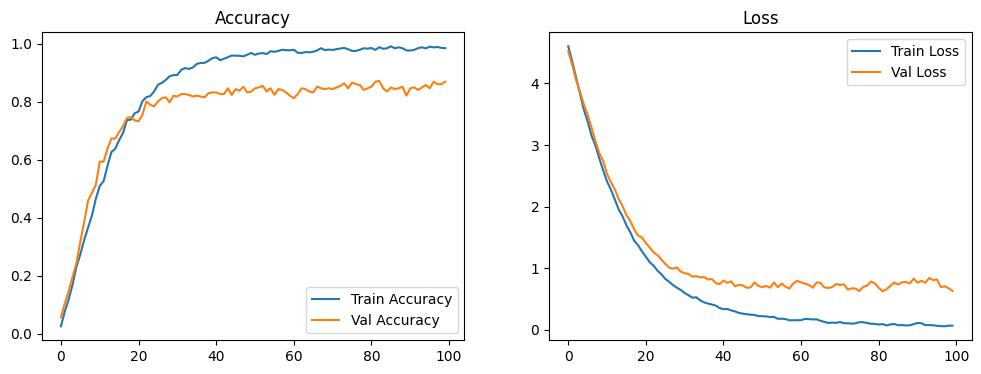

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

## Visualisasi Hasil Pelatihan CNN dan LSTM

## Classification Report

In [15]:
# Prediksi data testing
Y_pred = model_cnn_lstm.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Label kelas
class_names = sorted(os.listdir('data/augmented'))

print("=== Classification Report ===")
print(classification_report(
    Y_true,
    Y_pred_classes,
    target_names=class_names
))

28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 870ms/step
=== Classification Report ===
              precision    recall  f1-score   support

  akhiran-an       0.88      0.78      0.82         9
   akhiran-i       0.73      0.73      0.73        11
 akhiran-kan       0.80      0.80      0.80        10
 akhiran-man       0.88      0.70      0.78        10
 akhiran-nya       0.90      0.90      0.90        10
  akhiran-ti       0.73      1.00      0.84         8
 akhiran-wan       0.71      1.00      0.83        10
akhiran-wati       1.00      0.90      0.95        10
         apa       1.00      1.00      1.00        10
  awalan-ber       0.78      0.70      0.74        10
   awalan-di       0.78      0.78      0.78         9
   awalan-ke       0.78      0.78      0.78         9
   awalan-me       0.82      0.90      0.86        10
   awalan-pe       0.75      0.60      0.67        10
   awalan-se       0.70      0.88      0.78         8
  awalan-ter       1.00      0.88      0.93         8
        b

In [19]:
cm = confusion_matrix(Y_true, Y_pred_classes)
for i in range(cm.shape[0]):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    print(f"Kelas {i}")
    print(f"TP={TP}")
    print(f"TN={TN}")
    print(f"FP={FP}")
    print(f"FN={FN}")
    print("----------------")

Kelas 0
TP=7
TN=870
FP=1
FN=2
----------------
Kelas 1
TP=8
TN=866
FP=3
FN=3
----------------
Kelas 2
TP=8
TN=868
FP=2
FN=2
----------------
Kelas 3
TP=7
TN=869
FP=1
FN=3
----------------
Kelas 4
TP=9
TN=869
FP=1
FN=1
----------------
Kelas 5
TP=8
TN=869
FP=3
FN=0
----------------
Kelas 6
TP=10
TN=866
FP=4
FN=0
----------------
Kelas 7
TP=9
TN=870
FP=0
FN=1
----------------
Kelas 8
TP=10
TN=870
FP=0
FN=0
----------------
Kelas 9
TP=7
TN=868
FP=2
FN=3
----------------
Kelas 10
TP=7
TN=869
FP=2
FN=2
----------------
Kelas 11
TP=7
TN=869
FP=2
FN=2
----------------
Kelas 12
TP=9
TN=868
FP=2
FN=1
----------------
Kelas 13
TP=6
TN=868
FP=2
FN=4
----------------
Kelas 14
TP=7
TN=869
FP=3
FN=1
----------------
Kelas 15
TP=7
TN=872
FP=0
FN=1
----------------
Kelas 16
TP=8
TN=872
FP=0
FN=0
----------------
Kelas 17
TP=6
TN=872
FP=0
FN=2
----------------
Kelas 18
TP=7
TN=872
FP=0
FN=1
----------------
Kelas 19
TP=7
TN=868
FP=4
FN=1
----------------
Kelas 20
TP=6
TN=871
FP=1
FN=2
----------------
